In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import sys

# Globale Einstellungen für schönere Zahlen-Ausgabe (wie im vorigen Skript)
np.set_printoptions(formatter={'float_kind': lambda x: "{: .4f}".format(x)})

In [3]:
# Übertragungsfunktion H(z) = B(z) / A(z)
# Koeffizienten definieren
B = np.array([0.862, -1.219, 0.862])
A = np.array([1.0, -1.134, 0.604])

## a) Stabilität prüfen (Pole berechnen)

In [13]:
# In Python heißt der Befehl auch roots() (in numpy)
x12 = np.roots(A)

print("Pole (x12):")
print(x12)

print("Betrag der Pole:")
abs_x12 = np.abs(x12)
print(abs_x12)

# Überprüfung auf Stabilität
if np.any(abs_x12 > 1):
    print("System ist instabil")
else:
    print("System ist stabil")

Pole (x12):
[0.567+0.53151764j 0.567-0.53151764j]
Betrag der Pole:
[ 0.7772  0.7772]
System ist stabil


## b) Pol-Nullstellen-Plan (zplane Ersatz)

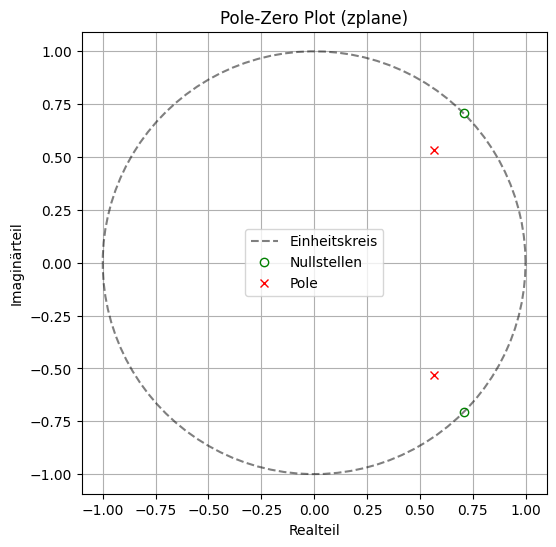

In [12]:
# Python hat kein natives 'zplane', wir bauen es mit Matplotlib

fvPoles = np.roots(A)
fvZeros = np.roots(B)

plt.figure(figsize=(6, 6))
# Einheitskreis zeichnen
angle = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(angle), np.sin(angle), 'k--', alpha=0.5, label='Einheitskreis')

# Pole (x) und Nullstellen (o) plotten
plt.plot(np.real(fvZeros), np.imag(fvZeros), 'go', fillstyle='none', label='Nullstellen')
plt.plot(np.real(fvPoles), np.imag(fvPoles), 'rx', label='Pole')

plt.grid(True)
plt.axis('equal') # Wichtig, damit der Kreis rund ist
plt.xlabel('Realteil')
plt.ylabel('Imaginärteil')
plt.title('Pole-Zero Plot (zplane)')
plt.legend()
plt.show()

## c) Frequenzgang

Frequenz bei min(|H|): 0.7854 rad/sample


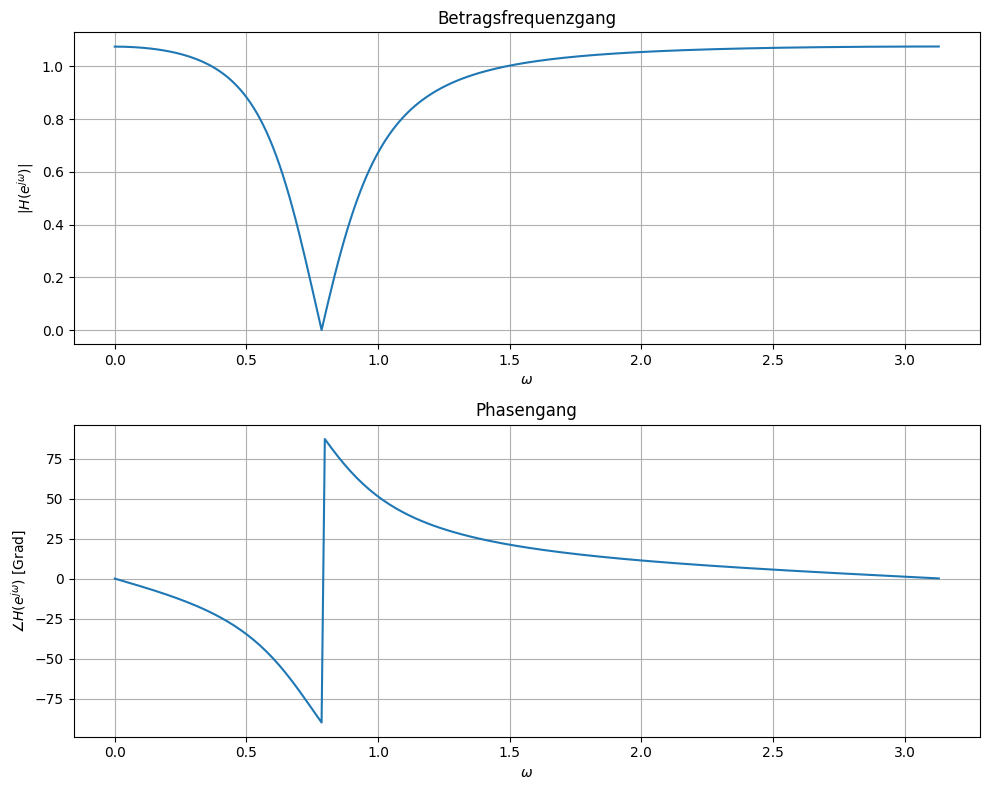

In [11]:
# freqz in Python:
# worN=256 entspricht der Anzahl der Punkte
# Rückgabe: w (Frequenzen in rad/sample), H (komplexer Frequenzgang)
w, H = signal.freqz(B, A, worN=256)

# Minimum des Betrags finden
abs_H = np.abs(H)
w_min_ind = np.argmin(abs_H)
print(f"Frequenz bei min(|H|): {w[w_min_ind]:.4f} rad/sample")

plt.figure(figsize=(10, 8))

# Betragsgang
plt.subplot(211)
plt.plot(w, abs_H)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$|H(e^{j\omega})|$')
plt.title('Betragsfrequenzgang')
plt.grid(True)

# Phasengang
# np.angle entspricht atan2(imag, real)
plt.subplot(212)
phase_deg = np.angle(H) * 180 / np.pi
plt.plot(w, phase_deg)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\angle H(e^{j\omega})$ [Grad]')
plt.title('Phasengang')
plt.grid(True)

plt.tight_layout()
plt.show()

## d) Impuls- und Sprungantwort (Filterung)

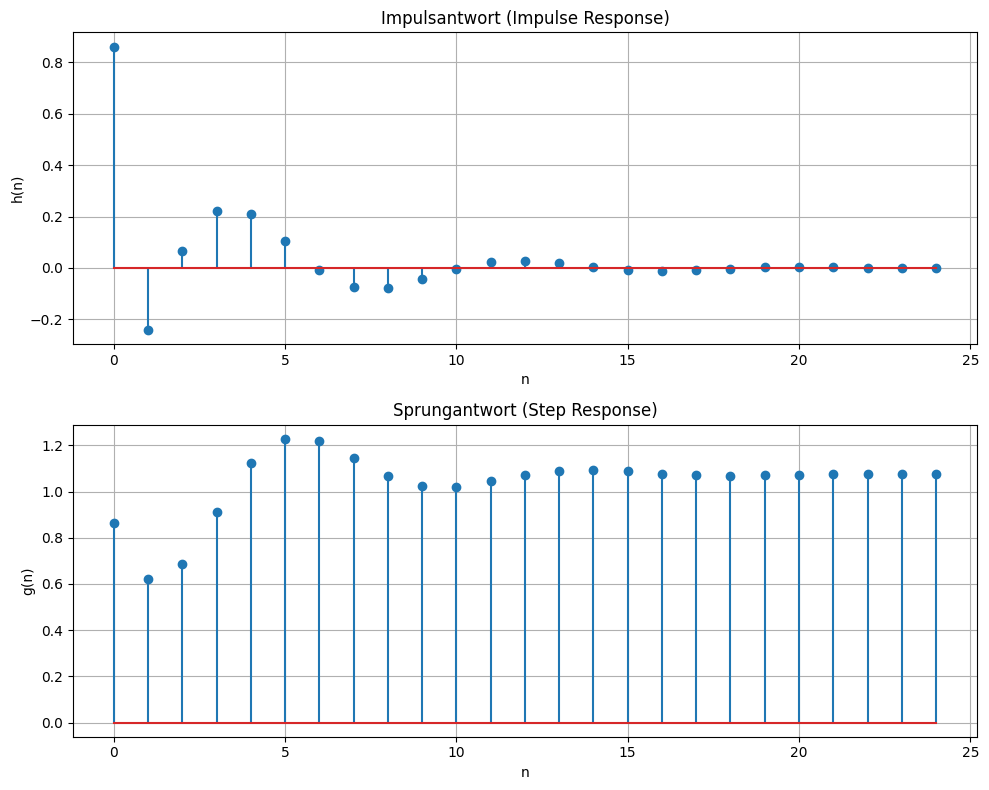

In [10]:
# Eingangssignale erstellen
N = 25
delta_inp = np.zeros(N)
delta_inp[0] = 1 # Dirac-Impuls

step_inp = np.ones(N) # Einheitssprung

# Filtern (lfilter ist das Äquivalent zu Matlab's filter)
# lfilter(b, a, x) -> Filtert Daten x mit Zähler b und Nenner a
h = signal.lfilter(B, A, delta_inp)
g = signal.lfilter(B, A, step_inp)

plt.figure(figsize=(10, 8))

# Impulsantwort plotten (stem plot)
plt.subplot(211)
plt.stem(np.arange(N), h)
plt.xlabel('n')
plt.ylabel('h(n)')
plt.title('Impulsantwort (Impulse Response)')
plt.grid(True)

# Sprungantwort plotten
plt.subplot(212)
plt.stem(np.arange(N), g)
plt.xlabel('n')
plt.ylabel('g(n)')
plt.title('Sprungantwort (Step Response)')
plt.grid(True)
plt.tight_layout()
plt.show()

## Alternativ 2024 (Systemtheorie Ansatz)

In [ ]:
# In Python nutzen wir dafür scipy.signal.dlti (Discrete Linear Time Invariant)
# oder direkt dimpulse/dstep.

# System definieren mit Abtastzeit dt=1 (oder -1 für unbestimmt, hier nehmen wir 1 für Plots)
system = signal.dlti(B, A, dt=1)

# dimpulse und dstep berechnen
# n=N gibt an, wie viele Punkte berechnet werden sollen
t_imp, y_imp = signal.dimpulse(system, n=N)
t_step, y_step = signal.dstep(system, n=N)

# Da dimpulse oft eine Liste von Arrays zurückgibt (für MIMO Systeme),
# müssen wir bei SISO Systemen mit [0] das erste Element greifen (y_imp[0]).
y_imp = np.squeeze(y_imp)
y_step = np.squeeze(y_step)

plt.figure(figsize=(10, 8))

plt.subplot(211)
plt.stem(t_imp, y_imp)
plt.xlabel('n')
plt.ylabel('h(n)')
plt.title('Alternative: Impulse Response (via dlti)')
plt.grid(True)

plt.subplot(212)
plt.stem(t_step, y_step)
plt.xlabel('n')
plt.ylabel('g(n)')
plt.title('Alternative: Step Response (via dlti)')
plt.grid(True)
plt.tight_layout()

plt.show()